In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
x_train = np.array([1.0, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5 ])
y_train = np.array([230, 280, 320, 360, 390, 400, 425])

In [4]:
def cost_value(X, y, b, w):
    m = X.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w*X[i] + b
        cost = (f_wb - y[i])**2
        cost_sum = cost_sum + cost
    total_cost = (1/(2*m)) * cost_sum
    return total_cost

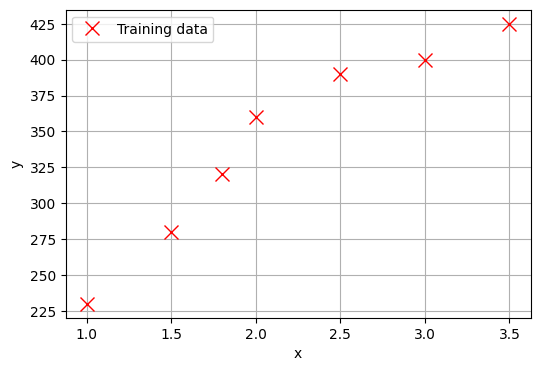

In [9]:
plt.figure(figsize=(6,4))
plt.plot(x_train, y_train, "rx",markersize = 10, label = "Training data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
w = 100
b = 50
cost = cost_value(x_train, y_train, b, w)
print(f"cost: {cost}")

cost: 3158.928571428571


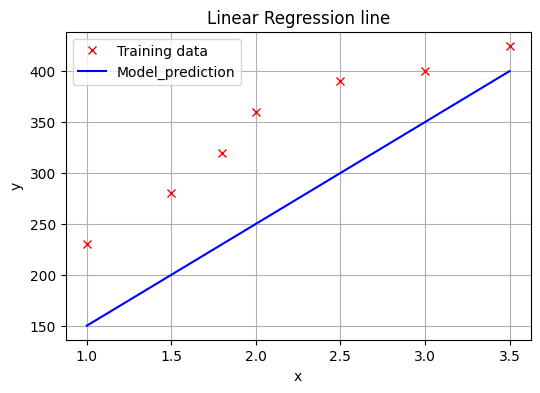

In [11]:
y_pred = w * x_train + b

plt.figure(figsize=(6, 4))
plt.plot(x_train, y_train, "rx", label = "Training data")
plt.plot(x_train, y_pred, "b-", label = "Model_prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression line")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
def compute_gradient(X, y, b, w):
    m = X.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w*X[i] + b
        error = f_wb - y[i]
        dj_dw += error * X[i]
        dj_db += error
    dj_dw /= m
    dj_db /= m

    return dj_db, dj_dw

In [14]:
def gradient_decent(X, y, w_init, b_init, alpha, num_iters):
    b = b_init
    w = w_init

    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient(X, y, b, w)

        b = b - alpha *dj_db
        w = w - alpha * dj_dw
        
        if i % 100 == 0:
            cost = cost_value(X, y, b, w)
            print(f"Iteration {i:4}: Cost {cost:.2f}, w = {w:.2f}, b = {b:.2f}")
    return b, w

In [18]:
b_init = 0
w_init = 0
alpha = 0.01
iteration = 1000

b_opt, w_opt = gradient_decent(x_train, y_train, b_init, w_init, alpha, iteration)
y_pred = w_opt * x_train + b_opt

Iteration    0: Cost 53785.05, w = 8.01, b = 3.44
Iteration  100: Cost 907.72, w = 122.38, b = 64.32
Iteration  200: Cost 772.36, w = 118.14, b = 75.14
Iteration  300: Cost 662.24, w = 114.16, b = 84.85
Iteration  400: Cost 572.59, w = 110.56, b = 93.61
Iteration  500: Cost 499.60, w = 107.32, b = 101.51
Iteration  600: Cost 440.18, w = 104.39, b = 108.64
Iteration  700: Cost 391.80, w = 101.75, b = 115.07
Iteration  800: Cost 352.41, w = 99.37, b = 120.88
Iteration  900: Cost 320.33, w = 97.22, b = 126.11


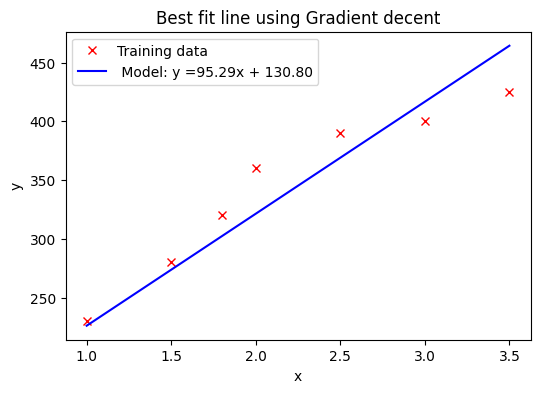

In [19]:
plt.figure(figsize = (6, 4))
plt.plot(x_train, y_train, "rx", label="Training data")
plt.plot(x_train, y_pred, "b-", label = f" Model: y ={w_opt:.2f}x + {b_opt:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Best fit line using Gradient decent")
plt.legend()
plt.show()